# Проект: Дашборд конверсий

## Импортируем библиотеки

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import requests as rq
from dotenv import load_dotenv
import os
%time

CPU times: total: 0 ns
Wall time: 13.4 μs


## Статистические расчёты

Выгружаем таблицы с помощью библиотеки **Pandas**

In [68]:
# Таблица visits
data_v = pd.read_csv('visits_1k.csv')
data_v.head(10)

,uuid,platform,user_agent,date
0,1de9ea66-70d3-4a1f-8735-df5ef7697fb9,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-03-01T13:29:22
1,f149f542-e935-4870-9734-6b4501eaf614,web,Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,2023-03-01T16:44:28
2,f149f542-e935-4870-9734-6b4501eaf614,web,Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,2023-03-06T06:12:36
3,08f0ebd4-950c-4dd9-8e97-b5bdf073eed1,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-03-01T20:16:37
4,08f0ebd4-950c-4dd9-8e97-b5bdf073eed1,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-03-05T17:42:47
5,19322fed-157c-49c6-b16e-2d5cabeb9592,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-03-01T20:29:03
6,19322fed-157c-49c6-b16e-2d5cabeb9592,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-03-03T00:13:55
7,04762a22-3c9f-40c9-9ac9-6628c4381836,web,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,2023-03-01T20:11:39
8,04762a22-3c9f-40c9-9ac9-6628c4381836,web,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,2023-03-05T15:15:30
9,04762a22-3c9f-40c9-9ac9-6628c4381836,web,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,2023-03-01T15:54:52


In [69]:
# Таблица regs
data_r = pd.read_csv('regs_1k.csv')
data_r.head(10)

,date,user_id,email,platform,registration_type
0,2023-03-01T00:25:39,8838849,joseph95@example.org,web,google
1,2023-03-01T14:53:01,8741065,janetsuarez@example.net,web,yandex
2,2023-03-01T14:27:36,1866654,robert67@example.org,web,google
3,2023-03-01T02:42:34,1577584,elam@example.net,web,apple
4,2023-03-01T10:27:14,4765395,stephanie68@example.net,web,yandex
5,2023-03-01T07:13:08,2241108,hatfieldmichael@example.com,web,yandex
6,2023-03-01T07:02:53,8643040,arthurgarrett@example.net,web,google
7,2023-03-01T16:49:03,130050,scottjacqueline@example.com,web,yandex
8,2023-03-01T02:51:34,4066354,laurensmith@example.net,web,email
9,2023-03-01T04:25:55,7340902,david71@example.org,web,yandex


## Запросы к API

In [70]:
# Запрос данных к registrations
df_registrations = pd.DataFrame(
    rq.get(
        'https://data-charts-api.hexlet.app/registrations',
        params={'begin': '2023-03-01', 'end': '2023-09-01'}
    ).json()
)
print(df_registrations)

                  datetime                               user_id  \
0      2023-03-01T07:40:13  2e0f6bb8-b029-4f45-a786-2b53990d37f1   
1      2023-03-01T13:14:00  f007f97c-9d8b-48b5-af08-119bb8f6d9b6   
2      2023-03-01T03:05:50  24ff46ae-32b3-4a74-8f27-7cf0b8f32f15   
3      2023-03-01T00:04:47  3e9914e1-5d73-4c23-b25d-b59a3aeb2b60   
4      2023-03-01T18:31:52  27f875fc-f8ce-4aeb-8722-0ecb283d0760   
...                    ...                                   ...   
21831  2023-08-31T07:32:08  a94b4a28-f25c-433c-b4ef-85af7d5b0c11   
21832  2023-08-31T23:25:50  fc709c6b-528b-40d8-8980-c2c278e5a628   
21833  2023-08-31T19:29:18  11e32805-7571-4108-8e50-e211d051bf7e   
21834  2023-08-31T19:38:54  bce7b818-768b-434a-b6af-573cd60bff7f   
21835  2023-08-31T08:36:05  fe03e08a-8e86-4b5f-9a50-c18a02b0d234   

                            email platform registration_type  
0               ebyrd@example.org      web            google  
1        knightgerald@example.org      web             em

In [71]:
# Запрос данных к visits
df_visits = pd.DataFrame(
    rq.get(
        'https://data-charts-api.hexlet.app/visits',
        params={'begin': '2023-03-01', 'end': '2023-09-01'}
    ).json()
)
print(df_visits)

                                    visit_id platform  \
0       ea3c939a-8d67-4616-ba89-7a41caffef66      web   
1       dacf4025-7670-4566-89a0-1b4b9e5cdf3a      web   
2       dacf4025-7670-4566-89a0-1b4b9e5cdf3a      web   
3       ea6871b4-da5c-42c9-9783-e16db10f8a2c      web   
4       ea6871b4-da5c-42c9-9783-e16db10f8a2c      web   
...                                      ...      ...   
263454  7e9be805-9834-49ff-9350-f5ea93211350      web   
263455  7e9be805-9834-49ff-9350-f5ea93211350      web   
263456  89702800-0abd-4971-a23d-d869bfd90aac      web   
263457  89702800-0abd-4971-a23d-d869bfd90aac      web   
263458  ea3c939a-8d67-4616-ba89-7a41caffef66      web   

                                               user_agent             datetime  
0       Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...  2023-04-05T20:45:29  
1       Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:15....  2023-04-08T23:55:33  
2       Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:15....  2023-04-07T22

Предварительный анализ таблицы visits

In [72]:
df_visits.describe()

,visit_id,platform,user_agent,datetime
count,263459,263459,263459,263459
unique,146085,4,32,261204
top,2cee521c-1747-4457-9e07-b186d6fdee05,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-04-08T13:14:25
freq,4,236301,13623,3


Предварительный анализ таблицы regs

In [73]:
df_registrations.describe()

,datetime,user_id,email,platform,registration_type
count,21836,21836,21836,21836,21836
unique,21821,21836,20868,3,4
top,2023-03-01T09:53:07,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ujones@example.com,android,email
freq,2,1,6,10582,8996


## Расчет метрик

In [74]:
def calculate_conversion(df_visits, df_registrations):
    
    # Преобразуем дату из формата с временем в просто дату
    df_visits['date'] = pd.to_datetime(df_visits['datetime']).dt.date
    df_registrations['date'] = pd.to_datetime(df_registrations['datetime']).dt.date
    
    # Убираем ботов и берём последний визит
    visits_clean = df_visits[
        ~df_visits['user_agent'].str.contains('bot', case=False, na=False)
    ].sort_values('date').groupby('visit_id').last().reset_index()
    
    # Группируем данные visits и registrations
    visits_grouped = visits_clean.groupby(['date', 'platform']).size().reset_index(name='visits')
    registrations_grouped = df_registrations.groupby(['date', 'platform']).size().reset_index(name='registrations')
    
    # Объединяем данные
    df_merge = pd.merge(visits_grouped, registrations_grouped, on=['date', 'platform'], how='outer').fillna(0)
    
    # Рассчитываем конверсию
    df_merge['conversion'] = (df_merge['registrations'] / df_merge['visits'] * 100).round(2)
    
    # Приводим данные к нужному формату
    df_merge = df_merge.rename(columns={'date': 'date_group'})
    result = df_merge.sort_values(['date_group', 'platform']).reset_index(drop=True)
    
    return result

# Сохраняем в формате .json
conversion_df = calculate_conversion(df_visits, df_registrations)
conversion_df.to_json('./conversion.json')

In [75]:
conversion_df.head()

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.33
1,2023-03-01,ios,22,18,81.82
2,2023-03-01,web,279,8,2.87
3,2023-03-02,android,67,59,88.06
4,2023-03-02,ios,31,24,77.42


## Добавляем рекламы

In [76]:
# Выгружаем таблицу рекламных кампаний
df_ads = pd.read_csv('ads.csv')

In [77]:
# Преобразуем дату
df_ads['date'] = pd.to_datetime(df_ads['date']).dt.date

# Агрегируем рекламные данные по дате и кампании
ads_grouped = (df_ads.groupby(['date', 'utm_campaign']).agg(cost=('cost', 'sum')).reset_index())

# Агрегируем рекламные данные по дате
ads_grouped = (ads_grouped
               .groupby('date')
               .agg(cost=('cost', 'sum'),
                    utm_campaign=('utm_campaign', lambda x: ', '.join(x) if not x.empty else 'none'))
               .reset_index())

# Переименуем date в date_group
ads_grouped.rename(columns={'date': 'date_group'}, inplace=True)

# Объединяем данные
conversion_df['date_group'] = pd.to_datetime(conversion_df['date_group']).dt.date
merged_df = pd.merge(conversion_df.groupby('date_group').agg(
                          visits=('visits', 'sum'),
                          registrations=('registrations', 'sum')).reset_index(), 
                        ads_grouped, 
                        on='date_group', 
                        how='left')

# Заполняем отсутствующие значения
merged_df['utm_campaign'] = merged_df['utm_campaign'].fillna('none')
merged_df['cost'] = merged_df['cost'].fillna(0)

# Составляем итоговую таблицу
result_ads = merged_df[['date_group', 'visits', 'registrations', 'cost', 'utm_campaign']]

# Сортируем данные по date_group
result_ads = result_ads.sort_values(by='date_group')

# Сохраняем итоговый датафрейм в формате .json
result_ads.to_json('./ads.json')

In [78]:
result_ads.head()

,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,376,87,212.0,advanced_algorithms_series
1,2023-03-02,613,106,252.0,advanced_algorithms_series
2,2023-03-03,683,107,202.0,advanced_algorithms_series
3,2023-03-04,647,159,223.0,advanced_algorithms_series
4,2023-03-05,707,115,265.0,advanced_algorithms_series


## Визуализация

### Итоговые визиты

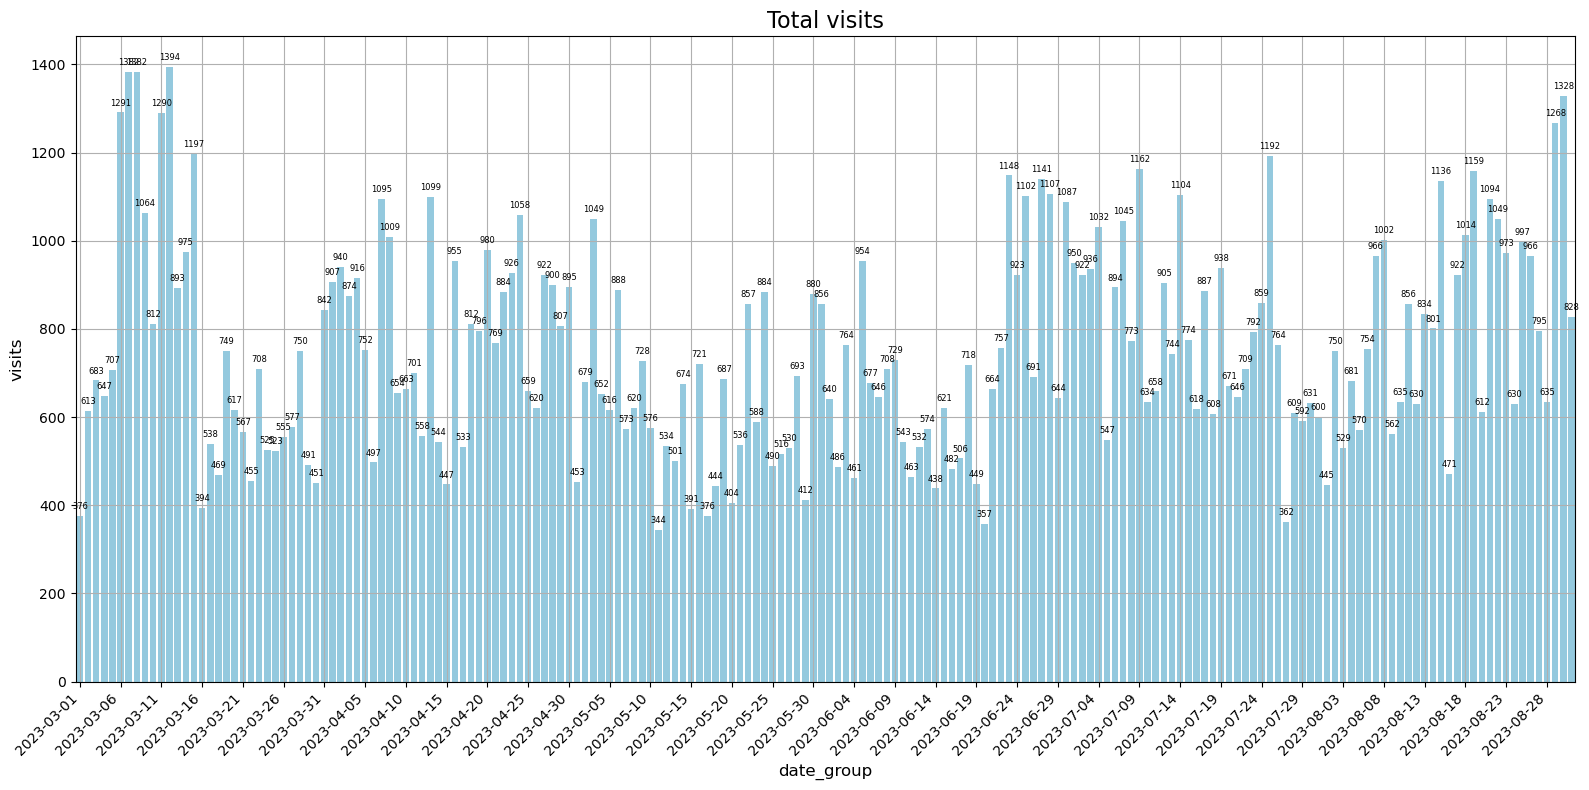

In [79]:
# Преобразуем дату
result_ads['date_group'] = pd.to_datetime(result_ads['date_group'])

# Создание графика
plt.figure(figsize=(16, 8))
bar_plot = sns.barplot(data=result_ads, x='date_group', y='visits', color='skyblue')

# Заголовки и метки
plt.title('Total visits', fontsize=16)
plt.xlabel('date_group', fontsize=12)
plt.ylabel('visits', fontsize=12)

# Настраиваем метки оси х
date_labels = result_ads['date_group'].dt.strftime('%Y-%m-%d')
step = 5  # показываем каждую 5‑ю дату
plt.xticks(
    ticks=range(0, len(date_labels), step),
    labels=date_labels[::step],
    rotation=45,
    ha='right'
)
for p in bar_plot.patches:
    bar_plot.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',                                        
        fontsize=6,                  
        xytext=(0, 5),     
        textcoords='offset points'
)

plt.tight_layout()
plt.grid(0.3)

# Сохраняем график
os.makedirs('./charts', exist_ok=True)
plt.savefig('./charts/total_visits.png', dpi=150, bbox_inches='tight')

plt.show()

### Итоговые визиты с разбивкой по платформам

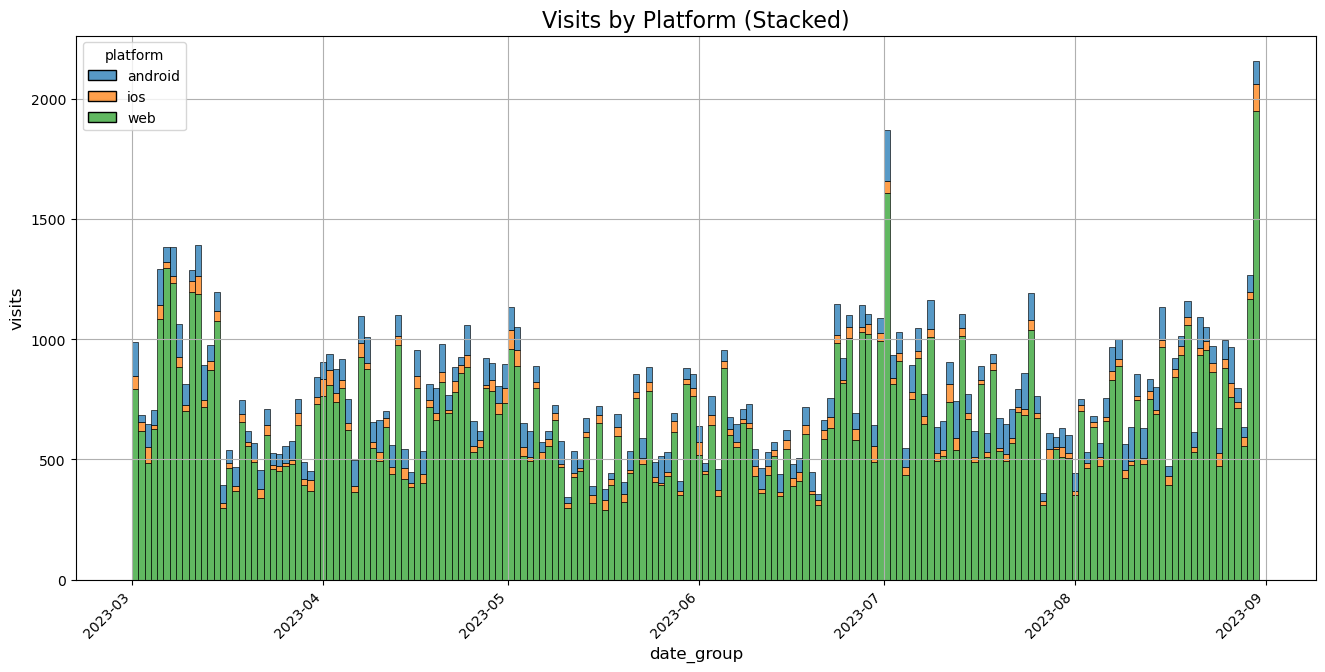

In [80]:
# Преобразуем дату
conversion_df['date_group'] = pd.to_datetime(conversion_df['date_group'])

# Создание графика
plt.figure(figsize=(16, 8))
ax = sns.histplot(
    data=conversion_df,
    x='date_group',
    weights='visits',
    hue='platform',
    multiple='stack',
    bins=180
)

# Заголовки и метки
plt.title('Visits by Platform (Stacked)',fontsize=16)
plt.xlabel('date_group',fontsize=12)
plt.ylabel('visits',fontsize=12)
plt.grid()
plt.gcf().autofmt_xdate(rotation=45, ha='right')

plt.savefig('./charts/visits_by_platform.png', dpi=150, bbox_inches='tight')
plt.show()

## Итоговые регистрации

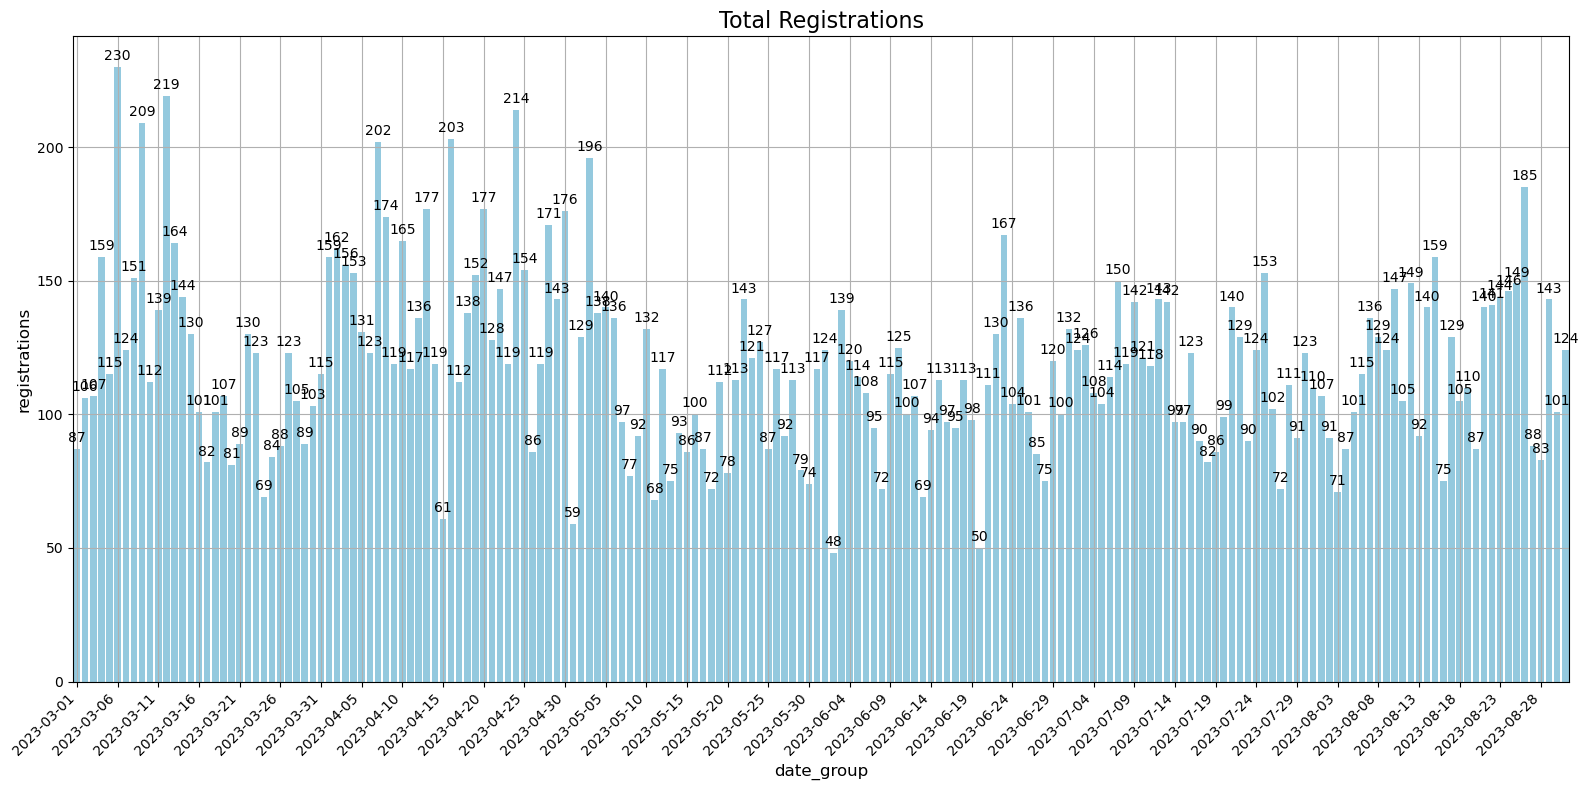

In [81]:
# Преобразуем дату
result_ads['date_group'] = pd.to_datetime(result_ads['date_group'])

# Создание графика
plt.figure(figsize=(16, 8))
bar_plot = sns.barplot(data=result_ads, x='date_group', y='registrations', color='skyblue')

# Заголовки и метки
plt.title('Total Registrations', fontsize=16)
plt.xlabel('date_group', fontsize=12)
plt.ylabel('registrations', fontsize=12)

# Настраиваем метки оси х
date_labels = result_ads['date_group'].dt.strftime('%Y-%m-%d')
step = 5  # показываем каждую 5‑ю дату
plt.xticks(
    ticks=range(0, len(date_labels), step),
    labels=date_labels[::step],
    rotation=45,
    ha='right'
)
for p in bar_plot.patches:
    bar_plot.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',                      
        xytext=(0, 5),     
        textcoords='offset points'
)

plt.tight_layout()
plt.grid(0.3)

# Сохраняем график
plt.savefig('./charts/total_registrations.png', dpi=150, bbox_inches='tight')

plt.show()

## Итоговые регистрации с разбивкой по платформам

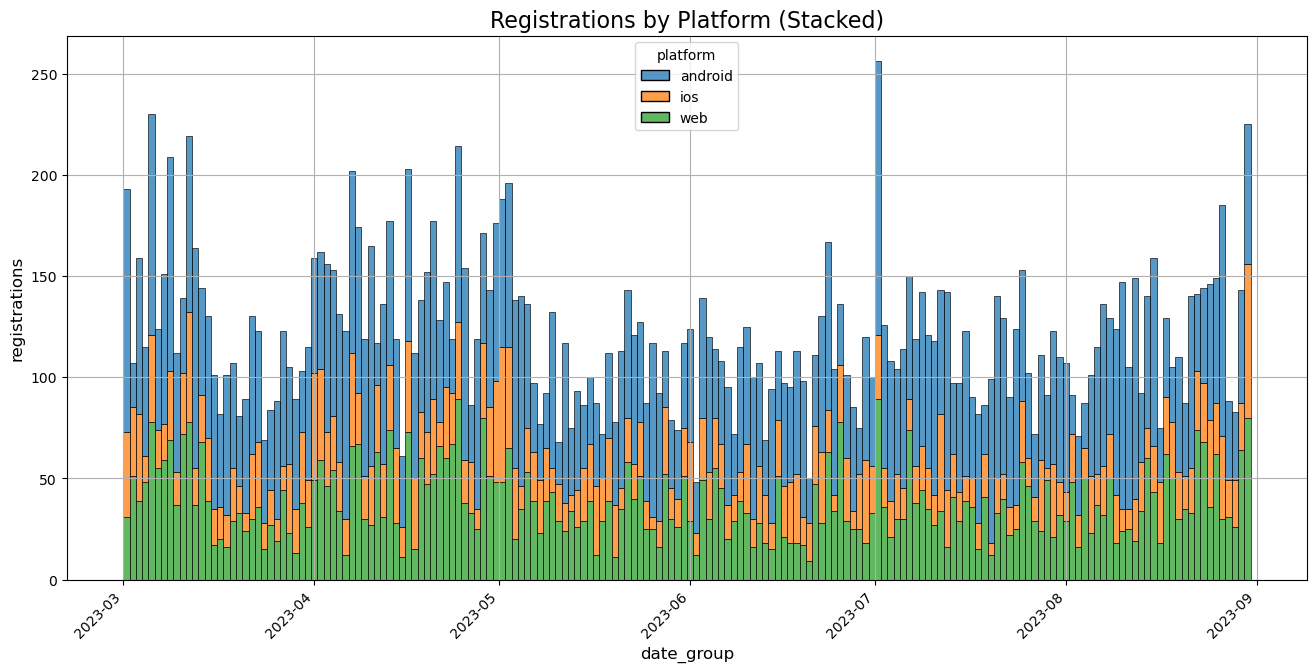

In [82]:
# Преобразуем дату
conversion_df['date_group'] = pd.to_datetime(conversion_df['date_group'])

# Создание графика
plt.figure(figsize=(16, 8))
ax = sns.histplot(
    data=conversion_df,
    x='date_group',
    weights='registrations',
    hue='platform',
    multiple='stack',
    bins=180
)

# Заголовки и метки
plt.title('Registrations by Platform (Stacked)',fontsize=16)
plt.xlabel('date_group',fontsize=12)
plt.ylabel('registrations',fontsize=12)
plt.grid()

# Поворот дат
plt.gcf().autofmt_xdate(rotation=45, ha='right')

# Сохраняем график
plt.savefig('./charts/registrations_by_platform.png', dpi=150, bbox_inches='tight')
plt.show()

## Итоговая конверсия

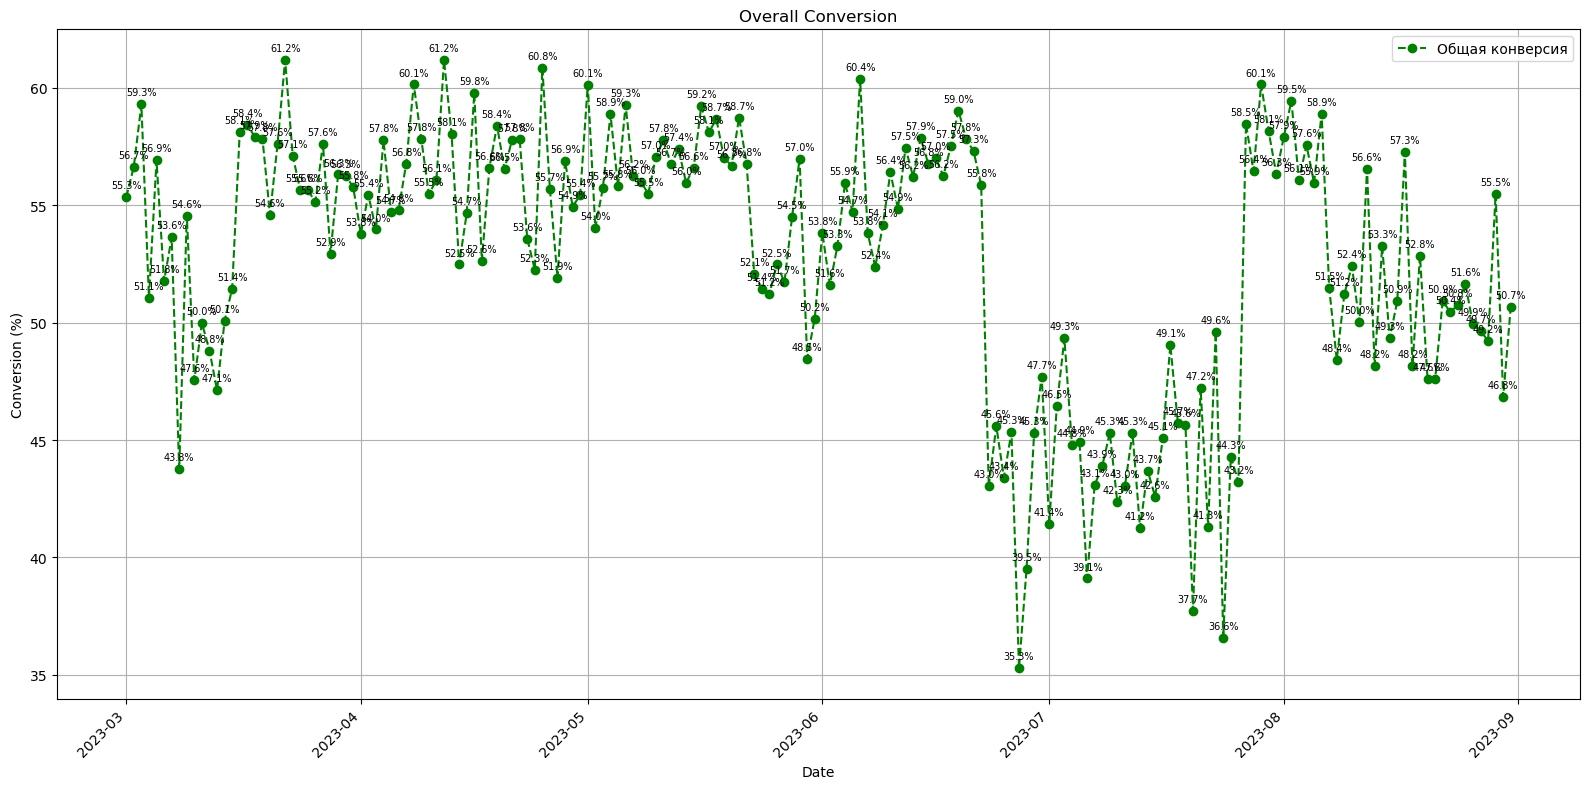

In [83]:
result_ads['date_group'] = pd.to_datetime(result_ads['date_group'])
conversion_data = conversion_df.groupby('date_group')['conversion'].mean().reset_index()

x = conversion_data['date_group']
y = conversion_data['conversion']

# Строим график
fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(
    x,
    y,
    marker='o',
    color='green',
    linestyle='--',
    label='Общая конверсия'
)

# Добавляем подписи значений на график
for i, row in conversion_data.iterrows():
    ax.annotate(
        f'{row["conversion"]:.1f}%',
        (row['date_group'], row['conversion']),
        ha='center',
        va='bottom',
        fontsize=7,
        xytext=(0, 5),
        textcoords='offset points'
    )

# Настройка осей
ax.set_xlabel('Date')
ax.set_ylabel('Conversion (%)')
ax.set_title('Overall Conversion')
ax.grid(True)
ax.legend()

# Поворот дат
fig.autofmt_xdate(rotation=45, ha='right')

# Компактное расположение
plt.tight_layout()

# Сохраняем
plt.savefig('./charts/overall_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

## Конверсия по каждой платформе

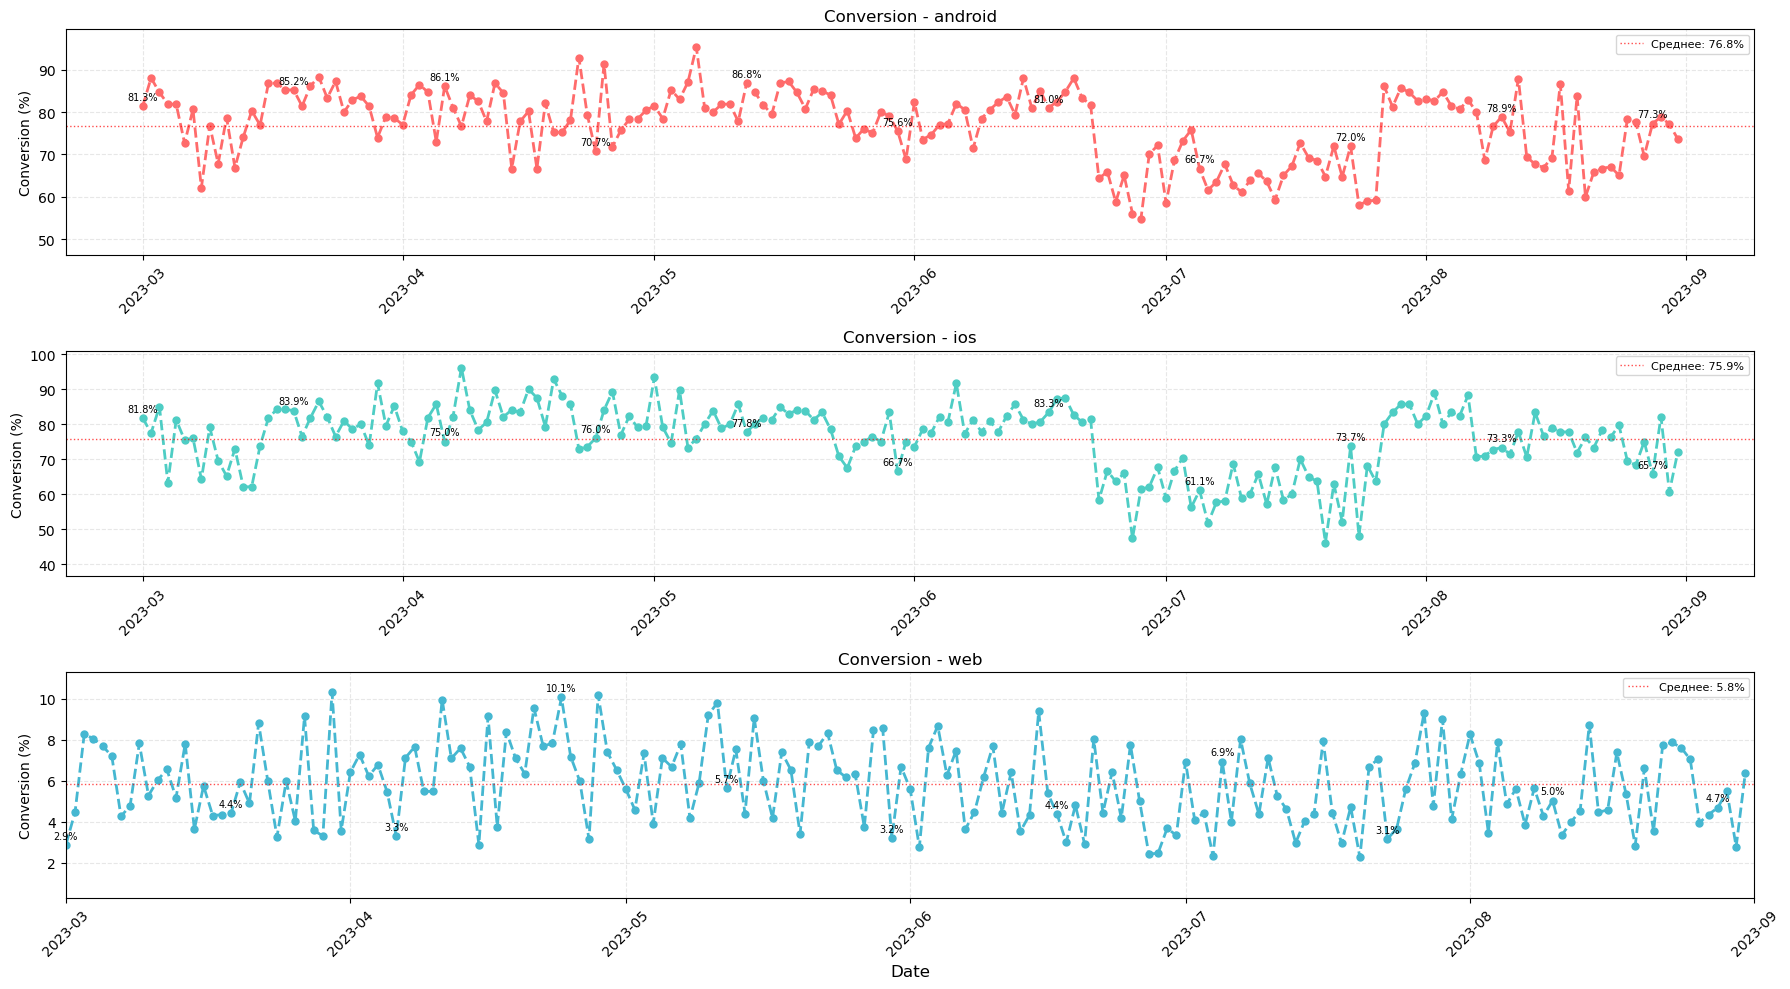

In [89]:
# Преобразуем дату
conversion_df['date_group'] = pd.to_datetime(conversion_df['date_group'])

# Подготавливаем данные по платформам
platforms = ['android', 'ios', 'web']

# Создаем подграфики
fig, axes = plt.subplots(3, 1, figsize=(18, 10))

for idx, platform in enumerate(platforms):
    # Фильтруем данные по платформе
    platform_data = conversion_df[conversion_df['platform'] == platform].groupby('date_group')['conversion'].mean()
    
    # Строим график
    axes[idx].plot(
        platform_data.index,
        platform_data.values,
        marker='o',
        color=colors[platform],
        linestyle='--',
        linewidth=2,
        markersize=5
    )
    
    # Добавляем подписи значений
    step = max(1, len(platform_data) // 10)
    for i, (date, value) in enumerate(platform_data.items()):
        if i % step == 0:
            axes[idx].annotate(
                f'{value:.1f}%',
                (date, value),
                ha='center',
                va='bottom',
                fontsize=7,
                xytext=(0, 3),
                textcoords='offset points'
            )
    
    # Индивидуальные границы Y
    y_min = max(0, platform_data.min() - platform_data.std())
    y_max = platform_data.max() + platform_data.std() * 0.5
    
    # Настройка каждого подграфика
    axes[idx].set_title(f'Conversion - {platform}', fontsize=12)
    axes[idx].set_ylabel('Conversion (%)', fontsize=10)
    axes[idx].grid(True, alpha=0.3, linestyle='--')
    axes[idx].set_ylim(y_min, y_max)
    
    # Добавляем среднюю линию
    avg_value = platform_data.mean()
    axes[idx].axhline(y=avg_value, color='red', linestyle=':', alpha=0.7, linewidth=1, label=f'Среднее: {avg_value:.1f}%')
    axes[idx].legend(loc='upper right', fontsize=8)

# Настройка общей оси X
axes[-1].set_xlabel('Date', fontsize=12)
axes[-1].set_xlim(pd.Timestamp('2023-03-01'), pd.Timestamp('2023-09-01'))

# Поворот дат
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('./charts/conversion_by_platforms.png', dpi=150, bbox_inches='tight')
plt.show()

## Стоимость реклам

In [ ]:
result_ads['date_group'] = pd.to_datetime(result_ads['date_group'])

# Настройка графика
plt.figure(figsize=(16, 8))
plt.plot(result_ads['date_group'],
         result_ads['cost'], 
         marker='o',
         linestyle='-',
         color='skyblue',
         linewidth=2,
         markersize=4)

# Добавление подписей для ненулевых значений
for idx, row in result_ads.iterrows():
    if row['cost'] == 0:
        continue
    plt.text(row['date_group'], row['cost'], f"{row['cost']:.0f}RUB", 
             ha='center', va='bottom', fontsize=8, rotation=45)

# Добавление подписей и заголовка
plt.title('Aggregated Ad Campaign Cost', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cost (RUB)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

# Сохранение и отображение графика
plt.savefig('./charts/ad_cost.png', dpi=150, bbox_inches='tight')
plt.show()

## Визиты за весь период с цветовым выделением рекламной кампании

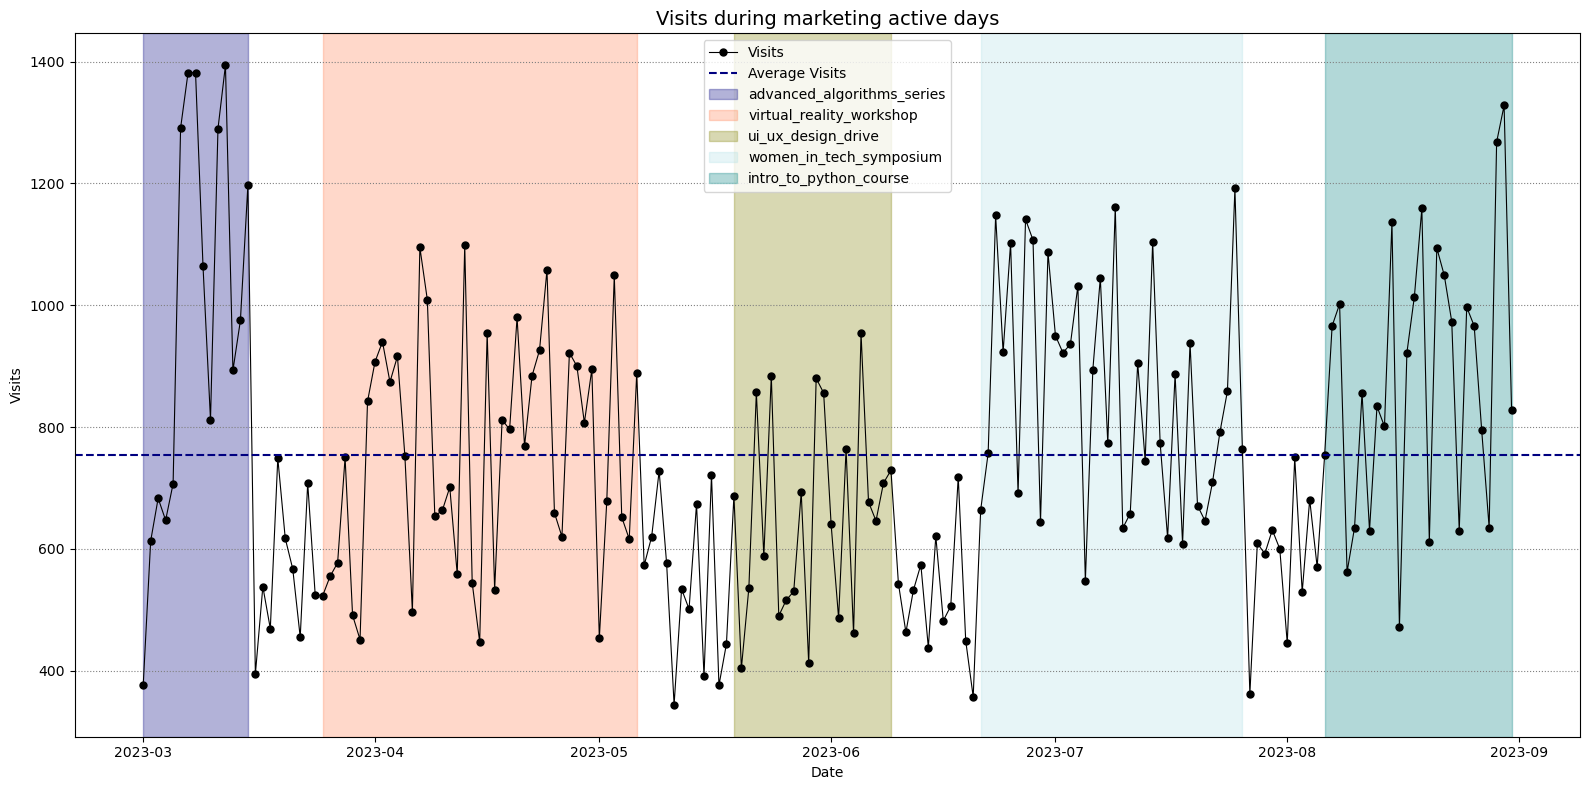

In [85]:
# Копируем данные и преобразуем дату
visits_color = result_ads.copy()
visits_color['date_group'] = pd.to_datetime(visits_color['date_group'])

# Создаём номера кампаний
visits_color['campaigns_n'] = (
    visits_color['utm_campaign'] != visits_color['utm_campaign'].shift()
).cumsum()

# Фильтруем данные
filtered_data = visits_color.dropna(subset=['utm_campaign']).query("utm_campaign != 'none'")


# Определяем периоды кампаний (начало и конец)
campaign_periods = (
    filtered_data
    .groupby(['campaigns_n', 'utm_campaign'])
    .agg(start=('date_group', 'min'), finish=('date_group', 'max'))
    .reset_index()
)

# Строим график
fig, ax = plt.subplots(figsize=(16, 8))

# Линия визитов
ax.plot(
    visits_color['date_group'],
    visits_color['visits'],
    linewidth=0.8,
    color='black',
    label='Visits',
    marker='o',
    markersize=5
)

# Средняя линия визитов
avg_visits = visits_color['visits'].mean()
ax.axhline(avg_visits, linestyle='--', color='navy', label='Average Visits')

# Цвета для областей кампаний
colors = ['navy', 'coral', 'olive', 'powderblue', 'teal']

# Добавляем цветные области для каждой кампании
for i, (_, row) in enumerate(campaign_periods.iterrows()):
    ax.axvspan(
        row['start'],
        row['finish'],
        color=colors[i % len(colors)],
        alpha=0.3,
        label=row['utm_campaign']
    )

# Оформление
ax.grid(axis='y', linestyle=':', color='grey')
ax.legend(loc='best')
ax.set_title('Visits during marketing active days', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Visits')
plt.tight_layout()
plt.savefig('./charts/visits_during_campaigns.png', dpi=150, bbox_inches='tight')
plt.show()


## Регистрации за весь период с цветовым выделением рекламной кампании

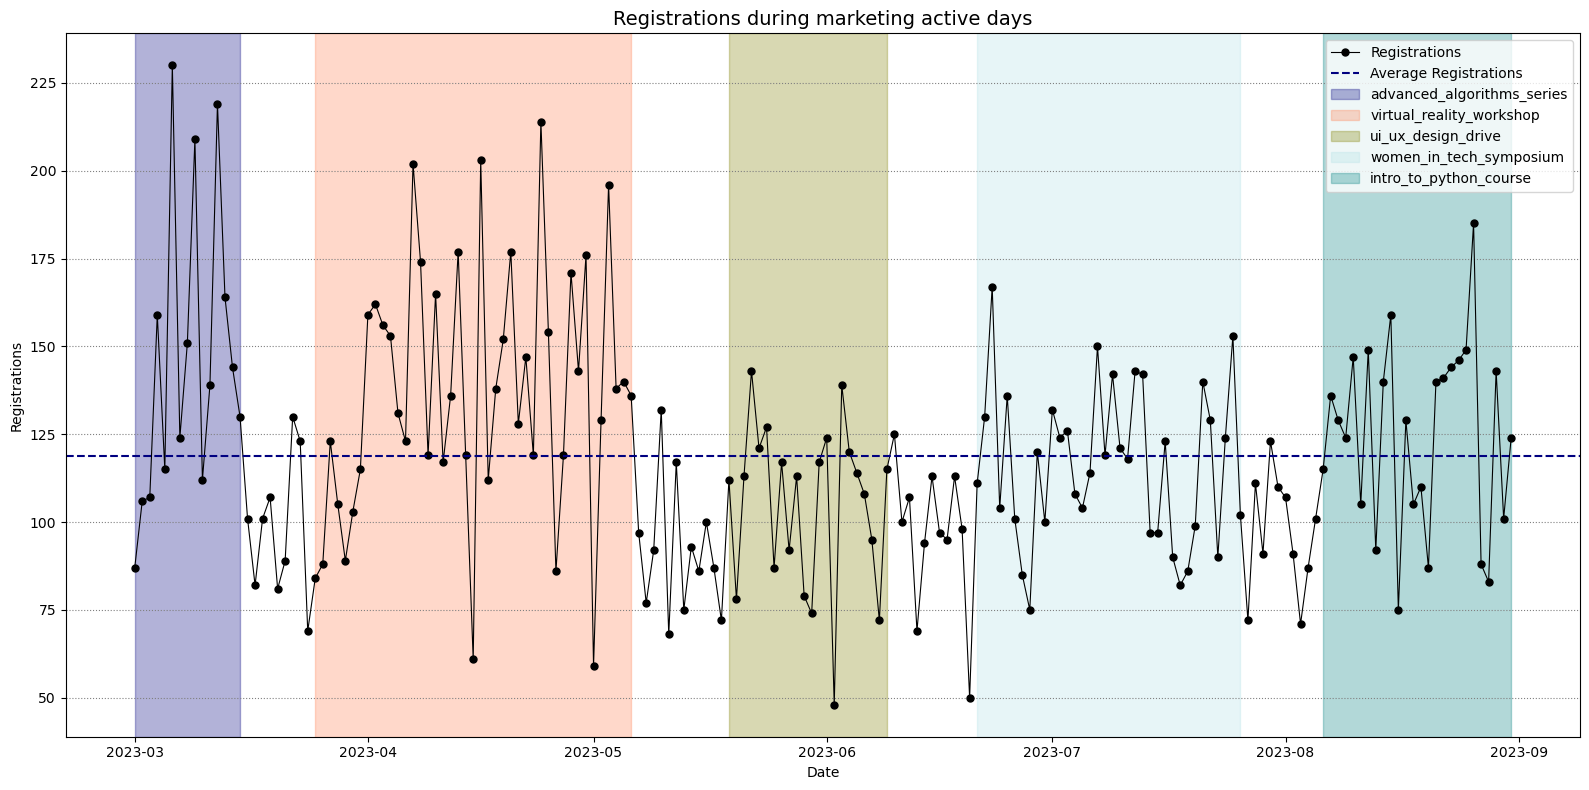

In [86]:
# Копируем данные и преобразуем дату
registrations_color = result_ads.copy()
registrations_color['date_group'] = pd.to_datetime(registrations_color['date_group'])

# Создаём номера кампаний
registrations_color['campaigns_n'] = (
    registrations_color['utm_campaign'] != registrations_color['utm_campaign'].shift()
).cumsum()

# Фильтруем данные
filtered_data = registrations_color.dropna(subset=['utm_campaign']).query("utm_campaign != 'none'")

# Определяем периоды кампаний (начало и конец)
campaign_periods = (
    filtered_data
    .groupby(['campaigns_n', 'utm_campaign'])
    .agg(start=('date_group', 'min'), finish=('date_group', 'max'))
    .reset_index()
)

# Строим график
fig, ax = plt.subplots(figsize=(16, 8))

# Линия регистраций
ax.plot(
    registrations_color['date_group'],
    registrations_color['registrations'],
    linewidth=0.8,
    color='black',
    label='Registrations',
    marker='o',
    markersize=5
)

# Средняя линия регистраций
avg_registrations = registrations_color['registrations'].mean()
ax.axhline(avg_registrations, linestyle='--', color='navy', label='Average Registrations')

# Цвета для областей кампаний
colors = ['navy', 'coral', 'olive', 'powderblue', 'teal']

# Добавляем цветные области для каждой кампании
for i, (_, row) in enumerate(campaign_periods.iterrows()):
    ax.axvspan(
        row['start'],
        row['finish'],
        color=colors[i % len(colors)],
        alpha=0.3,
        label=row['utm_campaign']
    )

# Оформление
ax.grid(axis='y', linestyle=':', color='grey')
ax.legend(loc='best')
ax.set_title('Registrations during marketing active days', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Registrations')
plt.tight_layout()
plt.savefig('./charts/registrations_during_campaigns.png', dpi=150, bbox_inches='tight')
plt.show()
